## Read and Setup the dataset

In [1]:
import pandas as pd
fp = "../data/monthly-car-sales.csv"
df = pd.read_csv(fp)

In [2]:
df

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587
...,...,...
103,1968-08,16722
104,1968-09,14385
105,1968-10,21342
106,1968-11,17180


In [3]:
cols = ["date", "signal"]
df.columns = cols

In [4]:
series = df.signal
series.index = df.date

## Prepare for SSA
1. Define Window Size
2. Run SSA
3. Inspect Eigen Value Plot


In [5]:
from ssalib import SingularSpectrumAnalysis
wdw = 24
ssa = SingularSpectrumAnalysis(series, window=wdw)

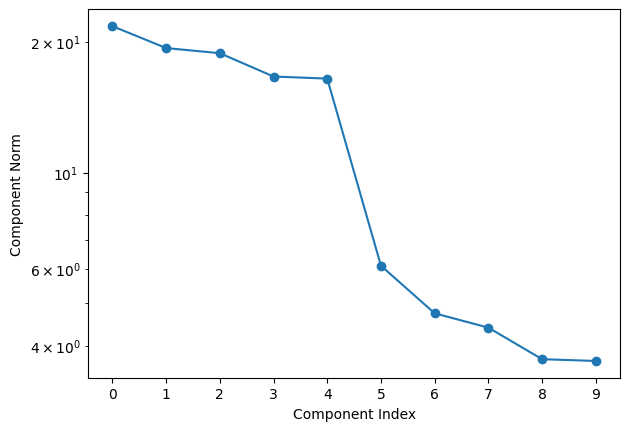

In [6]:
ssa.decompose()
# Visualize results, in this case, singular values
fig, ax = ssa.plot(kind='values', marker='o')

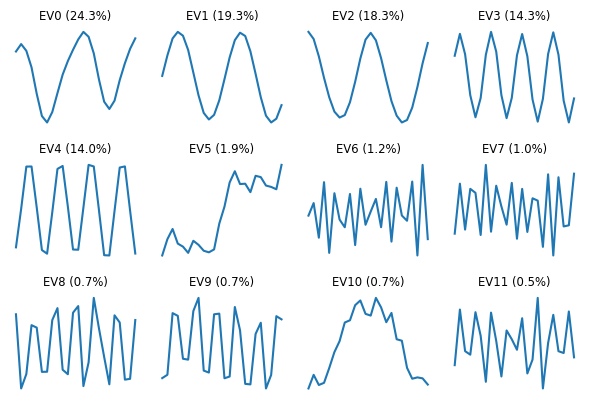

In [7]:
fig, axes = ssa.plot(kind='vectors')

## Apply Grouping

In [8]:
ssa.reconstruct(groups={'Trend': [0], 'Seasonal': [1,2,3,4,5,6,7], "residuals":[8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23]})

SingularSpectrumAnalysis(timeseries=<Series shape=(108,)>, window=24, svd_matrix='SSAMatrixType.BK_TRAJECTORY', svd_solver='numpy_standard', standardize=True)

## Residual Analysis

In [9]:
19.3 + 18.3 + 14.3 + 14.0

65.9

In [10]:
import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson

In [11]:

# 3. Perform the Durbin-Watson test
dw_statistic = durbin_watson(ssa["residuals"].values)

print(f"Durbin-Watson statistic: {dw_statistic}")

Durbin-Watson statistic: 2.230622021932288


<Axes: ylabel='Density'>

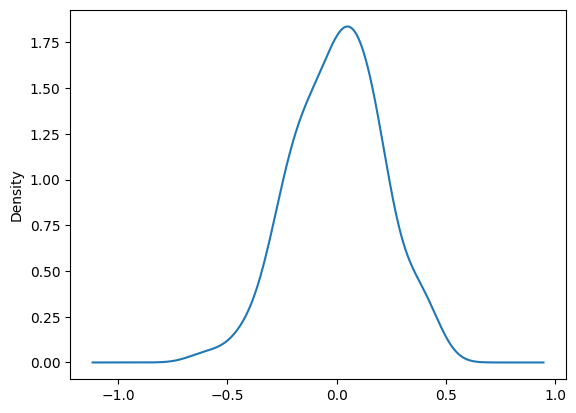

In [12]:
ssa["residuals"].plot.kde()

1. The residuals do not explain a lot of variation in the signal
2. Change point detection on the residuals, run with the assumption that we don't know the the change points apriori, with a
penalty $\beta = 2 . \log(N)$ suggests there are no change points in the noise. The implication is that unexplained variance does not change over the observation period. The change points of interest are in the trend and seasonal component.

<Axes: xlabel='date'>

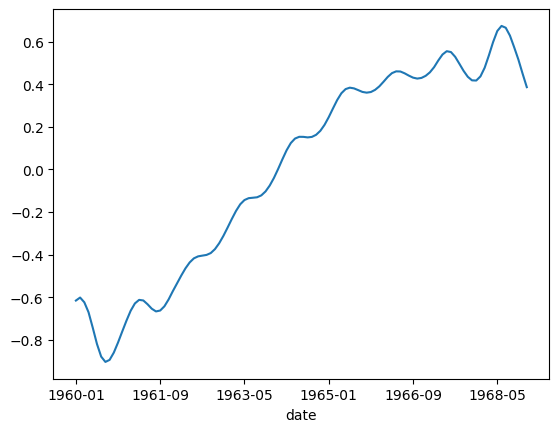

In [13]:
ssa["Trend"].plot()

<Axes: xlabel='date'>

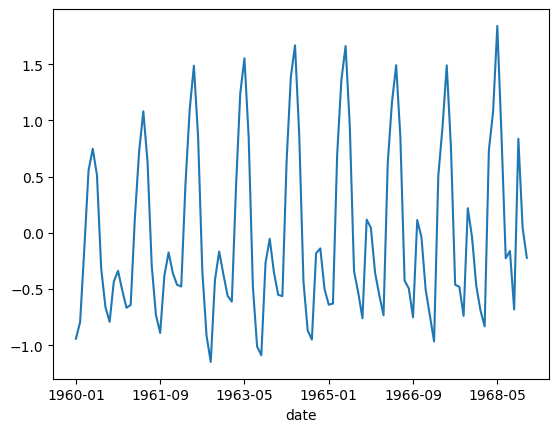

In [14]:
ssa["Seasonal"].plot()

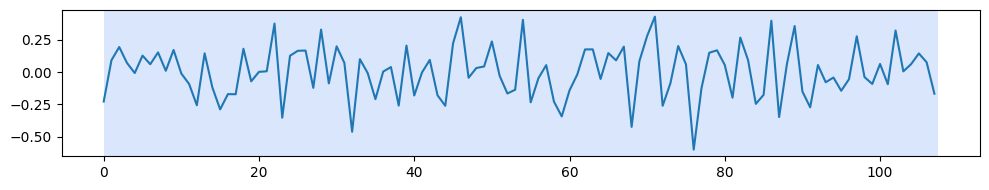

In [25]:
import ruptures as rpt
import matplotlib.pyplot as plt
from math import log
algo = rpt.Pelt(model="rbf").fit(ssa["residuals"].values)
rec_pen = 2*log(ssa["residuals"].shape[0],2)
# 3. Predict the change points
# The 'pen' parameter controls the sensitivity (higher penalty, fewer change points)
result = algo.predict(pen=rec_pen)

# 4. Display the results (optional, requires matplotlib)
rpt.display(ssa["residuals"].values, result)
plt.show()

## Knowledge Base Logging

In [16]:
from kmds.ontology.kmds_ontology import *
from kmds.tagging.tag_types import ExploratoryTags
kaw = KnowledgeExtractionExperimentationWorkflow("coffee_prices_35_year_analysis", namespace=onto)

In [17]:
from kmds.ontology.intent_types import IntentType
exp_obs_list = []
observation_count :int = 1
e1 = ExploratoryObservation(namespace=onto)

In [18]:
from google import genai
from google.genai import types
import os
from dotenv import load_dotenv

load_dotenv()   

True

In [19]:
model_observations = " 1. The dataset represents the monthly sales of cars in Quebec, Canada. It is available from kaggle\
(https://www.kaggle.com/datasets/hugoherrera11/monthly-car-sales).\
2. As with the other examples Singular Spectral Analysis was used to decompose the raw data into component signals.\
3. A window length of 24 (this is monthly data, so this represents a window of 2 years of sales data for each window) yielded\
best results (uncorrelated residuals with the durbin watson test).\
4. This dataset has a strong seasonal component - about two-thirds or the variation is from seasonality, trend accounts for a quarter of\
variation\
5. Clearly, this is a product that can benefit from data analysis such as this one. This can tell planners when to expect demand, \
and how much of the increase in demand is due to the trend component."


In [20]:

# Get AI response using the Gemini model
API_KEY = os.getenv("GEMINI_API_KEY")
client = genai.Client(api_key=API_KEY)
your_input = f"Can you summarize the following model observations succintly and return it as plain text string: {model_observations}"
response = client.models.generate_content(
model="gemini-2.5-flash",
contents=your_input,)

#response = model.generate_content(user_input)
ai_response = response.text

In [21]:
ai_response

'Singular Spectral Analysis (SSA) of monthly Quebec car sales, using an optimal 24-month window (validated by Durbin-Watson test), revealed strong seasonality (two-thirds of variation) and a significant trend (one-quarter of variation). This decomposition is highly beneficial for demand forecasting and understanding trend-driven demand.'

In [22]:

e1.finding = ai_response
e1.finding_sequence = observation_count
e1.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e1.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e1)

In [23]:
observation_count += 1
e2 = ExploratoryObservation(namespace=onto)
e2.finding = "Analysts should take note of the fact that the seasonal component dominates the trend component with this dataset.."
e2.finding_sequence = observation_count
e2.exploratory_observation_type = ExploratoryTags.DATA_QUALITY_OBSERVATION.value
e2.intent = IntentType.DATA_UNDERSTANDING.value
exp_obs_list.append(e2)
kaw.has_exploratory_observations = exp_obs_list

In [24]:
from owlready2 import *
from kmds.utils.path_utils import get_package_kb_path
KNOWLEDGE_BASE = "../data/kmds/car_sales_analysis.xml"
onto.save(file=KNOWLEDGE_BASE, format="rdfxml")